# 강화학습 포트폴리오 운용 (PPO)

**사전 조건**: `hybrid_model_colab.ipynb` 실행 후 Drive에 `rl_embeddings.h5` 존재

| 구성요소 | 내용 |
|----------|------|
| **State** | 5개 DTW 클러스터 평균 임베딩(5×64) + 현재 비중(5) = 325-dim |
| **Action** | 클러스터별 목표 포트폴리오 비중(5) |
| **Reward** | 일일 포트폴리오 수익률 − 거래비용(0.1%) |
| **알고리즘** | PPO (Stable-Baselines3) |

> 런타임 → 런타임 유형 변경 → **T4 GPU** 선택 후 실행

In [3]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q stable-baselines3[extra] gymnasium h5py pyarrow

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 18.1 MB/s eta 0:00:00


In [4]:
import warnings
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pathlib import Path
from collections import defaultdict

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['axes.unicode_minus'] = False

DRIVE_ROOT = Path('/content/drive/MyDrive/졸업프로젝트')
DATA_DIR   = DRIVE_ROOT / 'data'
MODEL_DIR  = DRIVE_ROOT / 'models'

RL_EMB_H5  = DATA_DIR / 'rl_embeddings.h5'
PARQUET    = DATA_DIR / 'kospi_valid.parquet'
CLUSTER_CSV= DATA_DIR / 'cluster_assignments.csv'

EMB_DIM    = 64
N_CLUSTERS = 5
TC         = 0.001   # 거래비용 (0.1%)
LOOKBACK   = 60      # hybrid 모델과 동일

# 학습/평가 기간 분리
TRAIN_START = '2021-01-01'
TRAIN_END   = '2023-12-31'
TEST_START  = '2024-01-01'
TEST_END    = '2025-12-31'

assert RL_EMB_H5.exists(), f'rl_embeddings.h5 없음 — hybrid_model_colab.ipynb 먼저 실행'
print('경로 확인 완료')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


경로 확인 완료


## 1. RL 임베딩 로드 & 인덱스 구축

In [5]:
print('rl_embeddings.h5 로드 중...')
with h5py.File(RL_EMB_H5, 'r') as f:
    tickers_raw = f['tickers'][:]
    dates_raw   = f['dates'][:]
    embs_all    = f['embeddings'][:]   # (N, 64)

tickers_list = [t.decode() for t in tickers_raw]
dates_list   = [d.decode() for d in dates_raw]

# (ticker, date) → 임베딩 인덱스
emb_index = {}
for i, (t, d) in enumerate(zip(tickers_list, dates_list)):
    emb_index[(t, d)] = i

print(f'임베딩: {embs_all.shape} | 인덱스: {len(emb_index):,}개')

rl_embeddings.h5 로드 중...
임베딩: (1077358, 64) | 인덱스: 1,077,358개


## 2. 가격 데이터 & 클러스터 로드

In [6]:
print('parquet 로드 중...')
raw_df = pd.read_parquet(PARQUET)
raw_df['Date'] = pd.to_datetime(raw_df['Date'])

cluster_df = pd.read_csv(CLUSTER_CSV)
cluster_df['종목코드'] = cluster_df['종목코드'].astype(str).str.zfill(6)
print(f'클러스터 분포:\n{cluster_df["cluster"].value_counts().sort_index()}')

# cluster → ticker list
cluster_tickers = defaultdict(list)
for _, row in cluster_df.iterrows():
    cluster_tickers[int(row['cluster'])].append(str(row['종목코드']))

# 클러스터별 일별 수익률 계산 (등가중 평균)
raw_df['종목코드'] = raw_df['종목코드'].astype(str).str.zfill(6)
raw_df = raw_df.sort_values(['종목코드', 'Date'])

# RetTarget_1d가 이미 있으면 사용, 없으면 Adj_Close로 계산
if 'RetTarget_1d' not in raw_df.columns:
    raw_df['RetTarget_1d'] = raw_df.groupby('종목코드')['Adj_Close'].pct_change()

ret_df = raw_df[['종목코드', 'Date', 'RetTarget_1d']].copy()
ret_df['date_str'] = ret_df['Date'].dt.strftime('%Y-%m-%d')

# (ticker, date) → return
ret_index = {}
for _, row in ret_df.iterrows():
    if not np.isnan(row['RetTarget_1d']):
        ret_index[(str(row['종목코드']), row['date_str'])] = float(row['RetTarget_1d'])

# 유효 날짜 목록 (전 클러스터에 임베딩이 존재하는 날짜)
all_date_strs = sorted(set(d for _, d in emb_index.keys()))
print(f'\n전체 날짜 수: {len(all_date_strs)}')

parquet 로드 중...
클러스터 분포:
cluster
0    108
1    112
2    118
3    299
4    120
Name: count, dtype: int64

전체 날짜 수: 1434


## 3. KospiPortfolioEnv (Gymnasium)

In [7]:
class KospiPortfolioEnv(gym.Env):
    """
    KOSPI DTW 클러스터 기반 포트폴리오 운용 환경

    State:  5개 클러스터 평균 임베딩(5×64) + 현재 비중(5) → 325-dim
    Action: 목표 포트폴리오 비중 (5-dim, Softmax 정규화)
    Reward: 일일 포트폴리오 수익률 − 거래비용
    """
    metadata = {'render_modes': []}

    def __init__(self, dates, emb_index, embs_all, ret_index,
                 cluster_tickers, n_clusters=5, emb_dim=64, tc=0.001):
        super().__init__()
        self.dates           = dates
        self.emb_index       = emb_index
        self.embs_all        = embs_all
        self.ret_index       = ret_index
        self.cluster_tickers = cluster_tickers
        self.n_clusters      = n_clusters
        self.emb_dim         = emb_dim
        self.tc              = tc

        obs_dim = n_clusters * emb_dim + n_clusters
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(obs_dim,), dtype=np.float32)
        self.action_space      = spaces.Box(-3.0, 3.0, shape=(n_clusters,), dtype=np.float32)

    def _cluster_emb(self, date_str):
        """각 클러스터의 평균 임베딩 반환 (64-dim × 5)"""
        cluster_embs = []
        for c in range(self.n_clusters):
            embs_c = []
            for ticker in self.cluster_tickers[c]:
                idx = self.emb_index.get((ticker, date_str))
                if idx is not None:
                    embs_c.append(self.embs_all[idx])
            if embs_c:
                cluster_embs.append(np.mean(embs_c, axis=0))
            else:
                cluster_embs.append(np.zeros(self.emb_dim, dtype=np.float32))
        return np.concatenate(cluster_embs)  # (5*64,)

    def _cluster_ret(self, date_str):
        """각 클러스터의 등가중 수익률 반환 (5-dim)"""
        rets = []
        for c in range(self.n_clusters):
            rs = [self.ret_index.get((t, date_str), np.nan)
                  for t in self.cluster_tickers[c]]
            rs = [r for r in rs if not np.isnan(r)]
            rets.append(float(np.mean(rs)) if rs else 0.0)
        return np.array(rets, dtype=np.float32)

    def _get_obs(self):
        date_str = self.dates[self.t]
        cluster_e = self._cluster_emb(date_str)
        return np.concatenate([cluster_e, self.weights]).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t               = 0
        self.weights         = np.ones(self.n_clusters, dtype=np.float32) / self.n_clusters
        self.portfolio_value = 1.0
        self.value_history   = [1.0]
        return self._get_obs(), {}

    def step(self, action):
        # Softmax로 비중 정규화
        action     = np.exp(action - action.max())
        action     = action / action.sum()

        # 거래비용
        tc_cost    = self.tc * np.abs(action - self.weights).sum()

        # 다음 날 수익률 (현재 날짜의 다음 날)
        next_t     = min(self.t + 1, len(self.dates) - 1)
        next_date  = self.dates[next_t]
        cluster_rets = self._cluster_ret(next_date)
        port_ret   = float((action * cluster_rets).sum())

        self.portfolio_value *= (1 + port_ret - tc_cost)
        self.weights          = action.copy()
        self.value_history.append(self.portfolio_value)
        self.t               += 1

        done = (self.t >= len(self.dates) - 1)
        reward = float(port_ret - tc_cost)

        info = {'portfolio_value': self.portfolio_value, 'port_ret': port_ret}
        return self._get_obs(), reward, done, False, info

In [8]:
# 학습/테스트 날짜 분리
train_dates = [d for d in all_date_strs if TRAIN_START <= d <= TRAIN_END]
test_dates  = [d for d in all_date_strs if TEST_START  <= d <= TEST_END]
print(f'학습 기간: {train_dates[0]} ~ {train_dates[-1]} ({len(train_dates)}일)')
print(f'테스트 기간: {test_dates[0]} ~ {test_dates[-1]} ({len(test_dates)}일)')

# 환경 생성
env_kwargs = dict(
    emb_index=emb_index, embs_all=embs_all,
    ret_index=ret_index, cluster_tickers=cluster_tickers,
    n_clusters=N_CLUSTERS, emb_dim=EMB_DIM, tc=TC,
)

train_env = Monitor(KospiPortfolioEnv(train_dates, **env_kwargs))
test_env  = KospiPortfolioEnv(test_dates, **env_kwargs)

# 환경 유효성 검사
print('\n환경 유효성 검사...')
check_env(KospiPortfolioEnv(train_dates[:100], **env_kwargs), warn=True)
print('OK')

학습 기간: 2021-01-04 ~ 2023-12-28 (737일)
테스트 기간: 2024-01-02 ~ 2025-12-30 (486일)

환경 유효성 검사...
OK


## 4. PPO 학습

In [9]:
%%time
eval_env = Monitor(KospiPortfolioEnv(train_dates[-120:], **env_kwargs))

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=str(MODEL_DIR),
    log_path=str(DATA_DIR / 'rl_logs'),
    eval_freq=5_000,
    deterministic=True,
    verbose=1,
)

ppo = PPO(
    'MlpPolicy',
    train_env,
    learning_rate=3e-4,
    n_steps=512,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,        # 탐험 유도
    vf_coef=0.5,
    max_grad_norm=0.5,
    policy_kwargs=dict(net_arch=[256, 256]),
    verbose=1,
    device='cpu',         # PPO는 CPU가 더 빠른 경우 많음
    seed=42,
)

ppo.learn(
    total_timesteps=300_000,
    callback=eval_callback,
    progress_bar=True,
)

ppo.save(str(MODEL_DIR / 'ppo_portfolio'))
print('PPO 모델 저장 완료: ppo_portfolio.zip')

Using cpu device
Wrapping the env in a DummyVecEnv.


Output()

----------------------------
| time/              |     |
|    fps             | 237 |
|    iterations      | 1   |
|    time_elapsed    | 2   |
|    total_timesteps | 512 |
----------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 736         |
|    ep_rew_mean          | -0.432      |
| time/                   |             |
|    fps                  | 191         |
|    iterations           | 2           |
|    time_elapsed         | 5           |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.006751788 |
|    clip_fraction        | 0.12        |
|    clip_range           | 0.2         |
|    entropy_loss         | -7.1        |
|    explained_variance   | -0.459      |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0908     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0131     |

Eval num_timesteps=5000, episode_reward=0.02 +/- 0.00

Episode length: 119.00 +/- 0.00

...

----------------------------------------
| eval/                   |            |
|    mean_ep_length       | 119        |
|    mean_reward          | -0.0434    |
| time/                   |            |
|    total_timesteps      | 295000     |
| train/                  |            |
|    approx_kl            | 0.01709178 |
|    clip_fraction        | 0.195      |
|    clip_range           | 0.2        |
|    entropy_loss         | -8.27      |
|    explained_variance   | 0.834      |
|    learning_rate        | 0.0003     |
|    loss                 | -0.0924    |
|    n_updates            | 5760       |
|    policy_gradient_loss | -0.00633   |
|    std                  | 1.3        |
|    value_loss           | 0.000647   |
----------------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 736      |
|    ep_rew_mean     | 0.323    |
| time/              |          |
|    fps             | 183      |
|    iterations  

Eval num_timesteps=300000, episode_reward=-0.04 +/- 0.00

Episode length: 119.00 +/- 0.00

-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 119         |
|    mean_reward          | -0.0424     |
| time/                   |             |
|    total_timesteps      | 300000      |
| train/                  |             |
|    approx_kl            | 0.011562544 |
|    clip_fraction        | 0.222       |
|    clip_range           | 0.2         |
|    entropy_loss         | -8.28       |
|    explained_variance   | 0.82        |
|    learning_rate        | 0.0003      |
|    loss                 | -0.111      |
|    n_updates            | 5850        |
|    policy_gradient_loss | -0.0109     |
|    std                  | 1.3         |
|    value_loss           | 0.000524    |
-----------------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 736      |
|    ep_rew_mean     | 0.323    |
| time/              |          |
|    fps             | 183      

PPO 모델 저장 완료: ppo_portfolio.zip
CPU times: user 26min 25s, sys: 11 s, total: 26min 36s
Wall time: 27min 20s


## 5. 백테스트 & 성과 평가

In [10]:
def run_backtest(env, model, deterministic=True):
    """환경에서 에피소드 1회 실행 → 포트폴리오 가치 곡선 반환"""
    obs, _ = env.reset()
    done   = False
    values = [1.0]
    while not done:
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, _, done, _, info = env.step(action)
        values.append(info['portfolio_value'])
    return np.array(values)


def equal_weight_backtest(env):
    """등가중 벤치마크: 매일 1/5씩 균등 배분"""
    obs, _ = env.reset()
    done   = False
    values = [1.0]
    action = np.ones(env.n_clusters, dtype=np.float32) / env.n_clusters
    while not done:
        obs, _, done, _, info = env.step(action)
        values.append(info['portfolio_value'])
    return np.array(values)


def compute_perf(values):
    """성과 지표 계산"""
    rets        = np.diff(values) / values[:-1]
    total_ret   = values[-1] / values[0] - 1
    annual_ret  = (1 + total_ret) ** (252 / len(rets)) - 1
    sharpe      = rets.mean() / (rets.std() + 1e-8) * np.sqrt(252)
    max_dd      = ((values / np.maximum.accumulate(values)) - 1).min()
    return {
        '총 수익률':   f'{total_ret*100:.2f}%',
        '연환산 수익률': f'{annual_ret*100:.2f}%',
        'Sharpe':     f'{sharpe:.3f}',
        'MDD':        f'{max_dd*100:.2f}%',
    }


print('백테스트 실행 중...')
ppo_values = run_backtest(test_env, ppo)
ew_values  = equal_weight_backtest(test_env)

print('\n[PPO 포트폴리오]')
for k, v in compute_perf(ppo_values).items():
    print(f'  {k}: {v}')
print('\n[등가중 벤치마크]')
for k, v in compute_perf(ew_values).items():
    print(f'  {k}: {v}')

백테스트 실행 중...

[PPO 포트폴리오]
  총 수익률: 137.22%
  연환산 수익률: 56.65%
  Sharpe: 2.473
  MDD: -12.55%

[등가중 벤치마크]
  총 수익률: 34.33%
  연환산 수익률: 16.57%
  Sharpe: 1.043
  MDD: -13.60%


## 6. 시각화

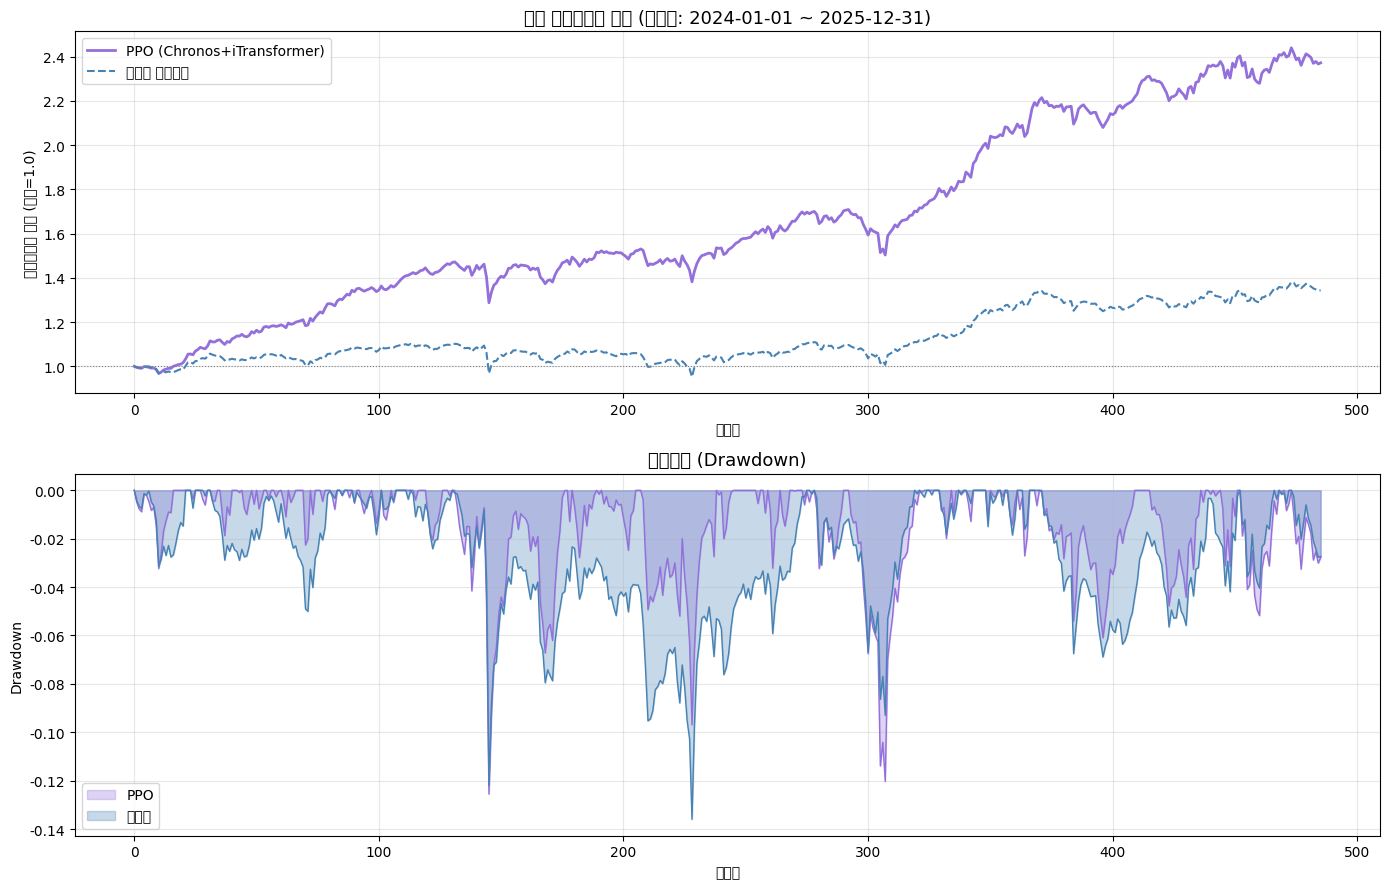

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# 누적 수익 곡선
ax = axes[0]
ax.plot(ppo_values, label='PPO (Chronos+iTransformer)', color='mediumpurple', lw=2)
ax.plot(ew_values,  label='등가중 벤치마크',             color='steelblue',   lw=1.5, ls='--')
ax.axhline(1, color='gray', lw=0.8, ls=':')
ax.set_title(f'누적 포트폴리오 가치 (테스트: {TEST_START} ~ {TEST_END})', fontsize=13)
ax.set_ylabel('포트폴리오 가치 (초기=1.0)')
ax.set_xlabel('거래일')
ax.legend()
ax.grid(alpha=0.3)

# 드로다운 곡선
ax2 = axes[1]
for vals, label, color in [
    (ppo_values, 'PPO',    'mediumpurple'),
    (ew_values,  '등가중', 'steelblue'),
]:
    dd = (vals / np.maximum.accumulate(vals)) - 1
    ax2.fill_between(range(len(dd)), dd, 0, alpha=0.3, color=color, label=label)
    ax2.plot(dd, color=color, lw=1)

ax2.set_title('드로다운 (Drawdown)', fontsize=13)
ax2.set_ylabel('Drawdown')
ax2.set_xlabel('거래일')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'rl_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# 성과 요약 저장
perf_df = pd.DataFrame({
    'PPO (Chronos+iTransformer)': compute_perf(ppo_values),
    '등가중 벤치마크':              compute_perf(ew_values),
}).T

print(perf_df.to_string())
perf_df.to_csv(DATA_DIR / 'rl_performance.csv', encoding='utf-8-sig')
print('\n저장 완료: rl_performance.csv, rl_backtest.png')
print()
print('▶ 다음 단계: 하이퍼파라미터 튜닝 (n_steps, ent_coef, net_arch)')
print('  또는 SAC 알고리즘으로 비교 실험')

                              총 수익률 연환산 수익률 Sharpe      MDD
PPO (Chronos+iTransformer)  137.22%  56.65%  2.473  -12.55%
등가중 벤치마크                     34.33%  16.57%  1.043  -13.60%

저장 완료: rl_performance.csv, rl_backtest.png

▶ 다음 단계: 하이퍼파라미터 튜닝 (n_steps, ent_coef, net_arch)
  또는 SAC 알고리즘으로 비교 실험
